# 04_Feature Extraction: ds002778 — Resting State EEG

**Author:** Fajar Laksono

## 0. Overview

This notebook transforms preprocessed EEG epochs into a tabular **feature matrix** suitable for classical machine learning and deep learning.

### 0.1. Findings from previous notebooks motivating feature choice

| Finding (EDA / Preprocessing) | Feature implication |
|---|---|
| PD-off shows ~30% higher **delta** power vs HC | Delta band power is a candidate discriminator |
| Both PD groups show slightly elevated **beta** | Beta power per channel, especially frontocentral |
| **Alpha** amplitude is similar across groups but spatially posterior | Relative alpha (posterior vs frontal) may be more informative than absolute |
| High inter-subject variability → group mean SEM bands overlap | Use **relative** (normalised) band power as primary features |
| 32 channels, 5 bands → 160 raw features for n=31 → severe overfitting risk | Also compute **ROI-averaged** features (4 regions × 5 bands = 20 features) |
| Some subjects have few epochs (min=22) | Average over all epochs per subject for robust estimates |

### 0.2. Features extracted

1. **Absolute band power** — per channel, per band (Welch PSD, log10-transformed)
2. **Relative band power** — absolute power normalized by broadband (1–40 Hz) total power
3. **Alpha peak frequency** — frequency of peak power in 6–14 Hz window (per channel, then median across channels)
4. **ROI-averaged features** — 4 scalp regions × 5 bands (absolute + relative)

### 0.3. Frequency bands

| Band | Range | Relevance | Associated With |
|------|-------|-----------|-----------------|
| Delta | 1–4 Hz | Cortical slowing in PD | Deep sleep, unconscious processes |
| Theta | 4–8 Hz | Memory / cognitive | Drowsiness, memory, meditation |
| Alpha | 8–13 Hz | Idling rhythm, visual cortex | Relaxed wakefulness, eyes closed, idle cortex |
| Beta | 13–30 Hz | Motor / basal ganglia synchrony | Active thinking, motor control, alertness |
| Gamma | 30–40 Hz | High-frequency processing | High-level cognition, sensory binding |

### 0.4. ROI (Region of Interest)  
| ROI | Channels | Brain Area |
|-----|----------|------------|
| Frontal | Fp1, Fp2, AF3, AF4, F7, F3, Fz, F4, F8 | Prefrontal & frontal lobe — cognition, executive function |
| Central | FC1, FC2, FC5, FC6, C3, Cz, C4 | Motor cortex — movement control (key for PD) | 
| Parietal | CP1, CP2, CP5, CP6, P3, Pz, P4, P7, P8 | Sensorimotor integration, spatial processing |
| Occipital | O1, Oz, O2, PO3, PO4 | Visual cortex — where alpha is strongest at rest |

### 0.5. Output files

| File | Contents |
|------|----------|
| `processed/features_all_channels.csv` | 46 rows × (32 ch × 5 bands × 2 power types + metadata) |
| `processed/features_roi.csv` | 46 rows × (4 ROI × 5 bands × 2 power types + metadata) — compact |
| `processed/features.csv` | Combined/merged feature set used by notebooks 05–07 |

## 1. Preparations

### 1.1. Import Libraries

In [1]:
import os
import warnings
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mne
from scipy.signal import welch
from scipy.stats import zscore

### 1.2. Configurations

In [2]:
mne.set_log_level('WARNING')
warnings.filterwarnings('ignore')

BIDS_ROOT   = os.path.join('datasets', 'ds002778')
PROC_DIR    = 'processed'
SFREQ       = 512.0          # Hz — from preprocessing
EPOCH_LEN   = 2.0            # seconds per epoch
N_FFT       = int(SFREQ * EPOCH_LEN)  # = 1024 samples per epoch → freq resolution 0.5 Hz

# ── Frequency bands ─────────────────────────────────────────────────────────
BANDS = {
    'delta': (1,  4),
    'theta': (4,  8),
    'alpha': (8, 13),
    'beta':  (13, 30),
    'gamma': (30, 40),
}
BROADBAND = (1, 40)  # total power normaliser

# ── ROI channel groups (standard 10-20, 32-ch BioSemi layout) ───────────────
ROIS = {
    'frontal':   ['Fp1', 'Fp2', 'AF3', 'AF4', 'F7', 'F3', 'Fz', 'F4', 'F8'],
    'central':   ['FC1', 'FC2', 'FC5', 'FC6', 'C3', 'Cz', 'C4'],
    'parietal':  ['CP1', 'CP2', 'CP5', 'CP6', 'P3', 'Pz', 'P4', 'P7', 'P8'],
    'occipital': ['O1', 'Oz', 'O2', 'PO3', 'PO4'],
}

# Alpha-peak search window
ALPHA_WIN = (6, 14)  # Hz — wider window to catch slow-peak subjects

print('Configuration:')
print(f'  PROC_DIR : {os.path.abspath(PROC_DIR)}')
print(f'  N_FFT    : {N_FFT}  → frequency resolution: {SFREQ/N_FFT:.2f} Hz')
print(f'  Bands    : {list(BANDS.keys())}')
print(f'  ROIs     : {list(ROIS.keys())}')

Configuration:
  PROC_DIR : D:\Project\Github\FajarLaksono\ai-neuro-EEG-ds002778-analysis\processed
  N_FFT    : 1024  → frequency resolution: 0.50 Hz
  Bands    : ['delta', 'theta', 'alpha', 'beta', 'gamma']
  ROIs     : ['frontal', 'central', 'parietal', 'occipital']


## 2. Load Preprocessed Epochs

Scan the `processed/` directory for all `*-epo.fif` files, extract subject/session/group metadata from filenames, and load each epochs object.

In [3]:
# ── Discover all epoch files ─────────────────────────────────────────────────
epo_files = sorted(glob.glob(os.path.join(PROC_DIR, '*-epo.fif')))
print(f'Found {len(epo_files)} epoch files:')

file_meta = []
for f in epo_files:
    fname = os.path.basename(f)
    # Filename format: sub-{id}_ses-{ses}-epo.fif
    parts = fname.replace('-epo.fif', '').split('_ses-')
    sub_id = parts[0].replace('sub-', '')   # e.g. 'hc1'
    ses    = parts[1]                        # e.g. 'hc', 'off', 'on'
    group  = 'HC' if 'hc' in sub_id.lower() else ('PD-off' if ses == 'off' else 'PD-on')
    label  = 0 if group == 'HC' else (1 if group == 'PD-off' else 2)
    file_meta.append({
        'subject': sub_id, 'session': ses, 'group': group, 'label': label, 'path': f
    })
    print(f'  {fname}  →  {group}')

meta_df = pd.DataFrame(file_meta)
print(f'\nGroup counts:')
print(meta_df['group'].value_counts())

Found 46 epoch files:
  sub-hc10_ses-hc-epo.fif  →  HC
  sub-hc18_ses-hc-epo.fif  →  HC
  sub-hc1_ses-hc-epo.fif  →  HC
  sub-hc20_ses-hc-epo.fif  →  HC
  sub-hc21_ses-hc-epo.fif  →  HC
  sub-hc24_ses-hc-epo.fif  →  HC
  sub-hc25_ses-hc-epo.fif  →  HC
  sub-hc29_ses-hc-epo.fif  →  HC
  sub-hc2_ses-hc-epo.fif  →  HC
  sub-hc30_ses-hc-epo.fif  →  HC
  sub-hc31_ses-hc-epo.fif  →  HC
  sub-hc32_ses-hc-epo.fif  →  HC
  sub-hc33_ses-hc-epo.fif  →  HC
  sub-hc4_ses-hc-epo.fif  →  HC
  sub-hc7_ses-hc-epo.fif  →  HC
  sub-hc8_ses-hc-epo.fif  →  HC
  sub-pd11_ses-off-epo.fif  →  PD-off
  sub-pd11_ses-on-epo.fif  →  PD-on
  sub-pd12_ses-off-epo.fif  →  PD-off
  sub-pd12_ses-on-epo.fif  →  PD-on
  sub-pd13_ses-off-epo.fif  →  PD-off
  sub-pd13_ses-on-epo.fif  →  PD-on
  sub-pd14_ses-off-epo.fif  →  PD-off
  sub-pd14_ses-on-epo.fif  →  PD-on
  sub-pd16_ses-off-epo.fif  →  PD-off
  sub-pd16_ses-on-epo.fif  →  PD-on
  sub-pd17_ses-off-epo.fif  →  PD-off
  sub-pd17_ses-on-epo.fif  →  PD-on
  sub-pd19_

## 3. Feature Extraction Functions

### 3.1. Band Power via Welch's Method

For each epoch, Welch's method estimates the PSD by averaging multiple overlapping FFT windows. We then integrate (sum) the PSD within each frequency band to get band power.

**Why Welch and not raw FFT?**  
- Welch reduces variance by averaging over overlapping segments — more stable estimates for short (2 s) epochs  
- `scipy.signal.welch` gives us direct control over window and overlap parameters
- Raw FFT is like listening for one second --you might catch a random noisse and think it's part of the song.
- Welch's method listens to the song in overlapping bits and averages them. It ignores the random "pops" and "clicks" (noise) and gives you the true melody.

**Integration formula:**  
$$P_{\text{band}} = \sum_{f \in [f_{\text{lo}}, f_{\text{hi}}]} \text{PSD}(f) \cdot \Delta f$$

> Easy Language: To find out how much "energy" is in a specific group (like the 8-12 Hz "Alpha" group), we just add up all the little bits of power in that range. It’s like counting all the $10 bills in your wallet to see how much "10-dollar power" you have.

**Relative power:**  
$$P_{\text{rel}} = \frac{P_{\text{band}}}{P_{\text{total}} (1\text{–}40\text{ Hz})}$$

Relative power removes global amplitude differences (electrode impedance, head size) and focuses on spectral *shape*, making it more robust for cross-subject comparisons.

> Easy Language: This is a percentage. If one person has a giant head and another has a tiny head, their raw brain signals will be different sizes. By calculating the percentage (e.g., "Alpha is 20% of the total brain noise"), we can compare them fairly. It doesn't matter if one "wallet" is bigger than the other; we just want to know the ratio of the cash inside.

**Explanation:**
- <u>Epoch:</u> is "Time slice", insteadd of looking at an hour of data, we chop it into small, 2 second chunks so they are easier to study.  
- <u>PSD (Power Spectral Density):</u> This is like a "Frequency Map". It tells us which "notes" the brain is playing. Is it playing a low, thumping bass (deep sleep) or high-pitched whistle (high focus)?
- <u>Welch's Method:</u> This is a "Smoother". If you take a photo of a moving car, it might be blurry. Welch's method takes several quick photoss and averages them out so you get a clear, steady picture of the brain's "notes".
- <u>FFT (Fast Fourier Transform):</u> The math tool that translates squiggly lines into frequencies.
- <u>Band Power:</u> This is the "Volume Control". It measures how load a sspecific group of notes is (e.g. "How load are the apha waves")

**Summary:**
1. We chop the data into slices (Epochs).
2. We smooth the data so it isn't jumpy (Welch’s).
3. We measure the volume of specific brain "notes" (Band Power).
4. We turn it into a percentage so we can compare different people (Relative Power).

In [4]:
def compute_band_powers(epoch_data, sfreq, bands, broadband):
    """
    Compute absolute and relative band power for a single epoch.

    Parameters
    ----------
    epoch_data : ndarray, shape (n_channels, n_times)
    sfreq      : float, sampling frequency in Hz
    bands      : dict {band_name: (f_low, f_high)}
    broadband  : tuple (f_low, f_high) for total power normalization

    Returns
    -------
    abs_powers : dict {band: ndarray shape (n_channels,)}
    rel_powers : dict {band: ndarray shape (n_channels,)}
    """
    n_ch, n_times = epoch_data.shape
    # Use the full epoch as one Welch segment (no sub-windowing)
    # nperseg = n_times gives exactly one segment → same as periodogram with Hann window
    freqs, psd = welch(epoch_data, fs=sfreq, nperseg=n_times, window='hann', axis=-1)
    freq_res = freqs[1] - freqs[0]  # Hz per bin

    # Total broadband power (denominator for relative power)
    bb_lo, bb_hi = broadband
    bb_mask = (freqs >= bb_lo) & (freqs < bb_hi)
    total_power = psd[:, bb_mask].sum(axis=1) * freq_res  # shape: (n_channels,)
    total_power = np.maximum(total_power, 1e-30)  # avoid div/0

    abs_powers = {}
    rel_powers = {}
    for band, (lo, hi) in bands.items():
        mask = (freqs >= lo) & (freqs < hi)
        abs_p = psd[:, mask].sum(axis=1) * freq_res   # V^2
        abs_powers[band] = abs_p
        rel_powers[band] = abs_p / total_power

    return abs_powers, rel_powers


def compute_alpha_peak_freq(epoch_data, sfreq, alpha_win):
    """
    Find the frequency of peak power in the alpha window for each channel.

    Returns
    -------
    peak_freqs : ndarray, shape (n_channels,)
    """
    n_ch, n_times = epoch_data.shape
    freqs, psd = welch(epoch_data, fs=sfreq, nperseg=n_times, window='hann', axis=-1)
    lo, hi = alpha_win
    mask = (freqs >= lo) & (freqs < hi)
    peak_idx = psd[:, mask].argmax(axis=1)
    return freqs[mask][peak_idx]  # shape: (n_channels,)


print('Feature extraction functions defined.')

Feature extraction functions defined.


## 4. Extract Features for All Subjects

For each subject:
1. Load preprocessed epochs (from `processed/`)
2. For each epoch, compute band powers and alpha peak frequency
3. **Average across all epochs** → one feature vector per subject-session

Averaging over epochs gives a robust subject-level estimate and avoids the class imbalance issue caused by different epoch counts per subject.

In [5]:
all_records = []   # one dict per subject-session

for _, row in meta_df.iterrows():
    path = row['path']
    try:
        epochs = mne.read_epochs(path, verbose=False, preload=True)
        ch_names = epochs.ch_names
        n_epochs = len(epochs)
        data = epochs.get_data()  # (n_epochs, n_channels, n_times)

        # Accumulate per-epoch features then average
        abs_acc  = {b: np.zeros((n_epochs, len(ch_names))) for b in BANDS}
        rel_acc  = {b: np.zeros((n_epochs, len(ch_names))) for b in BANDS}
        apf_acc  = np.zeros((n_epochs, len(ch_names)))  # alpha peak frequency

        for ei, epoch in enumerate(data):
            abs_p, rel_p = compute_band_powers(epoch, SFREQ, BANDS, BROADBAND)
            for b in BANDS:
                abs_acc[b][ei] = abs_p[b]
                rel_acc[b][ei] = rel_p[b]
            apf_acc[ei] = compute_alpha_peak_freq(epoch, SFREQ, ALPHA_WIN)

        # Subject-level averages across epochs
        abs_mean = {b: abs_acc[b].mean(axis=0) for b in BANDS}   # (n_channels,)
        rel_mean = {b: rel_acc[b].mean(axis=0) for b in BANDS}
        apf_mean = apf_acc.mean(axis=0)                           # (n_channels,)

        record = {
            'subject':  row['subject'],
            'session':  row['session'],
            'group':    row['group'],
            'label':    row['label'],
            'n_epochs': n_epochs,
            'ch_names': ch_names,
            # Store raw arrays for ROI computation later
            '_abs': abs_mean,
            '_rel': rel_mean,
            '_apf': apf_mean,
        }
        all_records.append(record)
        print(f'  {row["subject"]} {row["session"]}: {n_epochs} epochs -> OK')

    except Exception as e:
        print(f'  {row["subject"]} {row["session"]}: FAILED — {e}')

print(f'\nExtracted features for {len(all_records)}/{len(meta_df)} sessions.')

  hc10 hc: 96 epochs -> OK
  hc18 hc: 87 epochs -> OK
  hc1 hc: 55 epochs -> OK
  hc20 hc: 92 epochs -> OK
  hc21 hc: 32 epochs -> OK
  hc24 hc: 36 epochs -> OK
  hc25 hc: 99 epochs -> OK
  hc29 hc: 60 epochs -> OK
  hc2 hc: 89 epochs -> OK
  hc30 hc: 42 epochs -> OK
  hc31 hc: 83 epochs -> OK
  hc32 hc: 98 epochs -> OK
  hc33 hc: 93 epochs -> OK
  hc4 hc: 88 epochs -> OK
  hc7 hc: 79 epochs -> OK
  hc8 hc: 88 epochs -> OK
  pd11 off: 85 epochs -> OK
  pd11 on: 77 epochs -> OK
  pd12 off: 87 epochs -> OK
  pd12 on: 78 epochs -> OK
  pd13 off: 93 epochs -> OK
  pd13 on: 92 epochs -> OK
  pd14 off: 102 epochs -> OK
  pd14 on: 85 epochs -> OK
  pd16 off: 89 epochs -> OK
  pd16 on: 92 epochs -> OK
  pd17 off: 85 epochs -> OK
  pd17 on: 51 epochs -> OK
  pd19 off: 55 epochs -> OK
  pd19 on: 48 epochs -> OK
  pd22 off: 40 epochs -> OK
  pd22 on: 24 epochs -> OK
  pd23 off: 77 epochs -> OK
  pd23 on: 46 epochs -> OK
  pd26 off: 23 epochs -> OK
  pd26 on: 52 epochs -> OK
  pd28 off: 66 epochs 

## 5. Assemble Per-Channel Feature Matrix

Flatten band powers across all 32 channels into a single row per subject-session.

Column naming convention: `{abs|rel}_{band}_{channel}` (e.g., `abs_delta_Fp1`, `rel_alpha_Cz`)

Also include median alpha peak frequency across all channels and per-ROI alpha peak.

In [6]:
rows_ch = []

for rec in all_records:
    ch_names = rec['ch_names']
    row = {
        'subject':  rec['subject'],
        'session':  rec['session'],
        'group':    rec['group'],
        'label':    rec['label'],
        'n_epochs': rec['n_epochs'],
    }
    # Absolute and relative band power — per channel
    for band in BANDS:
        for ci, ch in enumerate(ch_names):
            row[f'abs_{band}_{ch}'] = rec['_abs'][band][ci]
            row[f'rel_{band}_{ch}'] = rec['_rel'][band][ci]
    # Alpha peak frequency — median across channels, and per-channel
    row['apf_median'] = float(np.median(rec['_apf']))
    for ci, ch in enumerate(ch_names):
        row[f'apf_{ch}'] = rec['_apf'][ci]
    rows_ch.append(row)

df_ch = pd.DataFrame(rows_ch)
print(f'Per-channel feature matrix: {df_ch.shape[0]} rows × {df_ch.shape[1]} columns')
print(f'  Metadata cols : 5  (subject, session, group, label, n_epochs)')
feature_cols = [c for c in df_ch.columns if c not in ['subject','session','group','label','n_epochs']]
print(f'  Feature cols  : {len(feature_cols)}')
df_ch.head(3)

Per-channel feature matrix: 46 rows × 358 columns
  Metadata cols : 5  (subject, session, group, label, n_epochs)
  Feature cols  : 353


,subject,session,group,label,n_epochs,abs_delta_Fp1,rel_delta_Fp1,abs_delta_AF3,rel_delta_AF3,abs_delta_F7,...,apf_C4,apf_T8,apf_FC6,apf_FC2,apf_F4,apf_F8,apf_AF4,apf_Fp2,apf_Fz,apf_Cz
0,hc10,hc,HC,0,96,9.237455e-12,0.185399,9.738899e-12,0.168920,2.887357e-11,...,10.338542,10.104167,9.432292,10.093750,10.104167,9.479167,9.973958,9.869792,10.057292,9.796875
1,hc18,hc,HC,0,87,1.901636e-11,0.415999,7.957388e-12,0.323342,1.003055e-11,...,10.241379,9.931034,9.568966,9.890805,9.534483,9.591954,9.649425,9.551724,9.252874,9.712644
2,hc1,hc,HC,0,55,3.118328e-11,0.255381,1.840394e-11,0.271836,1.678912e-11,...,11.136364,11.018182,10.854545,10.463636,10.600000,10.681818,10.363636,10.627273,10.100000,10.345455


## 6. Assemble ROI-Averaged Feature Matrix

Average band powers across channels within each scalp region.

**Rationale from EDA:**
- With n=31 subjects and 160 per-channel features, we risk severe overfitting
- ROI features reduce dimensionality to 4 regions × 5 bands = 20 features
- They remain interpretable and map cleanly onto known PD neuroscience (e.g., frontocentral beta, posterior alpha)

The ROI feature set will be the **primary input to the classical ML classifiers** in notebook 06.

In [7]:
rows_roi = []

for rec in all_records:
    ch_names = list(rec['ch_names'])
    row = {
        'subject':  rec['subject'],
        'session':  rec['session'],
        'group':    rec['group'],
        'label':    rec['label'],
        'n_epochs': rec['n_epochs'],
    }

    for roi_name, roi_chs in ROIS.items():
        # Only use channels that exist in this recording
        valid_chs = [c for c in roi_chs if c in ch_names]
        if not valid_chs:
            # Fill with NaN if none found
            for band in BANDS:
                row[f'abs_{band}_{roi_name}'] = np.nan
                row[f'rel_{band}_{roi_name}'] = np.nan
            row[f'apf_{roi_name}'] = np.nan
            continue

        idx = [ch_names.index(c) for c in valid_chs]
        for band in BANDS:
            row[f'abs_{band}_{roi_name}'] = rec['_abs'][band][idx].mean()
            row[f'rel_{band}_{roi_name}'] = rec['_rel'][band][idx].mean()
        row[f'apf_{roi_name}'] = rec['_apf'][idx].mean()

    # Global alpha peak frequency (median across all channels)
    row['apf_median'] = float(np.median(rec['_apf']))
    rows_roi.append(row)

df_roi = pd.DataFrame(rows_roi)
print(f'ROI feature matrix: {df_roi.shape[0]} rows × {df_roi.shape[1]} columns')
roi_feat_cols = [c for c in df_roi.columns if c not in ['subject','session','group','label','n_epochs']]
print(f'  Feature cols  : {len(roi_feat_cols)}')
print(f'  Columns: {roi_feat_cols}')
df_roi.head(3)

ROI feature matrix: 46 rows × 50 columns
  Feature cols  : 45
  Columns: ['abs_delta_frontal', 'rel_delta_frontal', 'abs_theta_frontal', 'rel_theta_frontal', 'abs_alpha_frontal', 'rel_alpha_frontal', 'abs_beta_frontal', 'rel_beta_frontal', 'abs_gamma_frontal', 'rel_gamma_frontal', 'apf_frontal', 'abs_delta_central', 'rel_delta_central', 'abs_theta_central', 'rel_theta_central', 'abs_alpha_central', 'rel_alpha_central', 'abs_beta_central', 'rel_beta_central', 'abs_gamma_central', 'rel_gamma_central', 'apf_central', 'abs_delta_parietal', 'rel_delta_parietal', 'abs_theta_parietal', 'rel_theta_parietal', 'abs_alpha_parietal', 'rel_alpha_parietal', 'abs_beta_parietal', 'rel_beta_parietal', 'abs_gamma_parietal', 'rel_gamma_parietal', 'apf_parietal', 'abs_delta_occipital', 'rel_delta_occipital', 'abs_theta_occipital', 'rel_theta_occipital', 'abs_alpha_occipital', 'rel_alpha_occipital', 'abs_beta_occipital', 'rel_beta_occipital', 'abs_gamma_occipital', 'rel_gamma_occipital', 'apf_occipital', '

,subject,session,group,label,n_epochs,abs_delta_frontal,rel_delta_frontal,abs_theta_frontal,rel_theta_frontal,abs_alpha_frontal,...,abs_theta_occipital,rel_theta_occipital,abs_alpha_occipital,rel_alpha_occipital,abs_beta_occipital,rel_beta_occipital,abs_gamma_occipital,rel_gamma_occipital,apf_occipital,apf_median
0,hc10,hc,HC,0,96,1.462768e-11,0.221749,4.793194e-12,0.100499,7.729499e-12,...,5.389167e-12,0.111897,8.940135e-12,0.170246,2.346641e-11,0.451387,1.828233e-12,0.040309,9.758333,9.992188
1,hc18,hc,HC,0,87,1.016812e-11,0.362043,2.112952e-12,0.102115,6.481002e-12,...,1.756553e-12,0.100207,1.045484e-11,0.462712,2.679031e-12,0.154838,3.857985e-13,0.024307,9.245977,9.531609
2,hc1,hc,HC,0,55,1.706209e-11,0.269425,3.743606e-12,0.086657,5.529635e-12,...,3.281296e-12,0.081797,1.604845e-11,0.312264,1.157558e-11,0.279812,3.882178e-12,0.099625,11.390909,10.731818


## 7. Log-Transform Absolute Power

EEG power values span several orders of magnitude (~10⁻¹² to 10⁻⁹ V²/Hz).
Log₁₀-transforming absolute power:
- Compresses the dynamic range
- Makes the distribution more Gaussian (required for linear classifiers and t-tests)
- Is standard practice in EEG/MEG spectral analysis

Relative power is already bounded in [0,1] and does not require log-transform.

> The Problem: "The Giant Scale"Brain signals (EEG) are incredibly tiny. As shown in your image, they are measured in values like $10^{-12}$.Imagine you are trying to measure the height of everything in the universe. Some things are as small as an ant (0.01 meters), and some are as big as a mountain (8,000 meters). If you try to put them on the same graph, the ant will look like a flat line at zero. You can't see the detail of the ant because the mountain is so huge.  
>
> The Solution: Log-TransformationA Log-Transform (specifically $log_{10}$) is like a magical lens that "squishes" big numbers and "stretches" tiny ones so they can sit on the same graph and look normal.Compresses the range: It turns those tiny $10^{-12}$ numbers into much simpler numbers like -12.Makes it "Gaussian": In baby language, this means making the data look like a nice, symmetrical Bell Curve. Most computer math (like the t-tests you might use in your studies) only works well if the data looks like a Bell Curve.

In [8]:
def log_transform_abs(df):
    """Apply log10 to all columns starting with 'abs_'."""
    df = df.copy()
    abs_cols = [c for c in df.columns if c.startswith('abs_')]
    df[abs_cols] = np.log10(df[abs_cols].clip(lower=1e-30))
    return df

df_ch  = log_transform_abs(df_ch)
df_roi = log_transform_abs(df_roi)

# Quick check: a few abs_ columns should now be negative (log10 of tiny values)
abs_sample = [c for c in df_roi.columns if c.startswith('abs_')][:3]
print('Sample log10(abs) values:')
print(df_roi[['group'] + abs_sample].groupby('group').mean().round(2))

Sample log10(abs) values:
        abs_delta_frontal  abs_theta_frontal  abs_alpha_frontal
group                                                          
HC                 -10.75             -11.33             -11.26
PD-off             -10.44             -11.09             -11.09
PD-on              -10.58             -11.09             -11.17


**Explanation:** 
- Before the transform, these were numbers with ten or eleven zeros after the decimal point (0.00000000001).
- Now, they are simple numbers that a machine learning model or a statistical test can easily compare.

## 8. Assemble Combined Feature Matrix

The combined `features.csv` merges ROI features (primary ML input) with the global alpha peak frequency.
The per-channel features are saved separately for deep learning or future analysis.

In [9]:
# features.csv = df_roi  (already contains apf_median + per-ROI apf)
df_features = df_roi.copy()

print('Feature matrix (features.csv):')
print(f'  Shape  : {df_features.shape}')
print(f'  Groups : {df_features["group"].value_counts().to_dict()}')
print()
display(df_features.describe().round(4))

Feature matrix (features.csv):
  Shape  : (46, 50)
  Groups : {'HC': 16, 'PD-off': 15, 'PD-on': 15}



,label,n_epochs,abs_delta_frontal,rel_delta_frontal,abs_theta_frontal,rel_theta_frontal,abs_alpha_frontal,rel_alpha_frontal,abs_beta_frontal,rel_beta_frontal,...,abs_theta_occipital,rel_theta_occipital,abs_alpha_occipital,rel_alpha_occipital,abs_beta_occipital,rel_beta_occipital,abs_gamma_occipital,rel_gamma_occipital,apf_occipital,apf_median
count,46.0000,46.0000,46.0000,46.0000,46.0000,46.0000,46.0000,46.0000,46.0000,46.0000,...,46.0000,46.0000,46.0000,46.0000,46.0000,46.0000,46.0000,46.0000,46.0000,46.0000
mean,0.9783,73.5217,-10.5938,0.3483,-11.1742,0.1409,-11.1761,0.1895,-11.0498,0.2461,...,-11.2021,0.1535,-10.9526,0.2708,-11.1207,0.2084,-11.8115,0.0516,9.0324,9.0168
std,0.8297,24.0257,0.3411,0.1236,0.3050,0.0530,0.3459,0.0970,0.2669,0.0800,...,0.2980,0.0668,0.4233,0.1378,0.2495,0.0726,0.2954,0.0331,0.7806,0.7553
min,0.0000,22.0000,-11.1652,0.1439,-11.6751,0.0623,-11.8041,0.0504,-11.6475,0.1086,...,-11.7965,0.0818,-11.7163,0.0891,-11.6337,0.0891,-12.4136,0.0123,6.8038,6.7949
25%,0.0000,54.2500,-10.8433,0.2544,-11.4316,0.1026,-11.4918,0.1202,-11.2243,0.1862,...,-11.3650,0.1082,-11.3458,0.1476,-11.3046,0.1529,-12.0381,0.0224,8.5942,8.5794
50%,1.0000,84.0000,-10.6152,0.3424,-11.2069,0.1335,-11.1196,0.1648,-10.9831,0.2376,...,-11.2519,0.1439,-10.9185,0.2299,-11.1253,0.1951,-11.8585,0.0464,9.0928,9.0246
75%,2.0000,92.0000,-10.3233,0.4058,-10.9932,0.1670,-10.9171,0.2458,-10.8515,0.2927,...,-11.0423,0.1704,-10.6506,0.3640,-10.9240,0.2536,-11.5557,0.0652,9.4392,9.5303
max,2.0000,103.0000,-9.7992,0.7292,-10.4954,0.3476,-10.4102,0.4750,-10.6444,0.4617,...,-10.5660,0.4341,-10.0524,0.5809,-10.6296,0.4514,-11.2069,0.1609,11.3909,10.7318


## 9. Save Feature Matrices

In [10]:
path_roi   = os.path.join(PROC_DIR, 'features_roi.csv')
path_ch    = os.path.join(PROC_DIR, 'features_all_channels.csv')
path_feat  = os.path.join(PROC_DIR, 'features.csv')

df_roi.to_csv(path_roi,  index=False)
df_ch.to_csv(path_ch,   index=False)
df_features.to_csv(path_feat, index=False)

print(f'Saved:')
print(f'  {path_roi}   — {df_roi.shape}')
print(f'  {path_ch}  — {df_ch.shape}')
print(f'  {path_feat}        — {df_features.shape}')

Saved:
  processed\features_roi.csv   — (46, 50)
  processed\features_all_channels.csv  — (46, 358)
  processed\features.csv        — (46, 50)


## 10. Exploratory Visualization

Visualize extracted features to verify correctness and identify the most discriminative features for the classification stage.

### 10.1. Relative Band Power by Group and ROI
#### 10.1.1. Visualization

This heatmap shows mean relative band power per group per ROI — the single most useful overview for checking that the features replicate the EDA spectral findings. Tese heatmaps gave us the "Average/Mean" for each group.

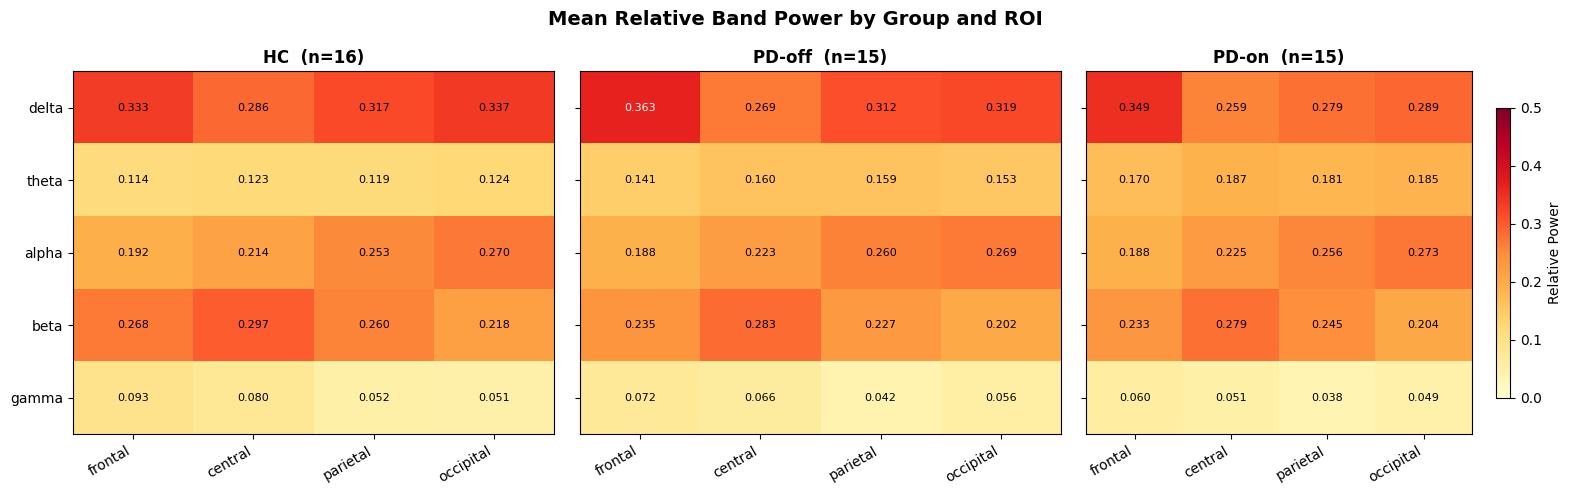

In [11]:
groups = ['HC', 'PD-off', 'PD-on']
band_names = list(BANDS.keys())
roi_names  = list(ROIS.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, grp in zip(axes, groups):
    sub_df = df_roi[df_roi['group'] == grp]
    # Build matrix: bands × ROIs
    mat = np.zeros((len(band_names), len(roi_names)))
    for bi, band in enumerate(band_names):
        for ri, roi in enumerate(roi_names):
            col = f'rel_{band}_{roi}'
            mat[bi, ri] = sub_df[col].mean() if col in sub_df.columns else np.nan
    im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.5)
    ax.set_xticks(range(len(roi_names)))
    ax.set_xticklabels(roi_names, rotation=30, ha='right')
    ax.set_yticks(range(len(band_names)))
    ax.set_yticklabels(band_names)
    ax.set_title(f'{grp}  (n={len(sub_df)})', fontweight='bold')
    for bi in range(len(band_names)):
        for ri in range(len(roi_names)):
            ax.text(ri, bi, f'{mat[bi, ri]:.3f}', ha='center', va='center', fontsize=8,
                    color='black' if mat[bi, ri] < 0.35 else 'white')

plt.colorbar(im, ax=axes[-1], shrink=0.8, label='Relative Power')
plt.suptitle('Mean Relative Band Power by Group and ROI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### 10.1.2. Summary
- Redder/Darker: The brain is spending a LOT of its energy budget there (like Delta).
- Lighter/Yellow: The brain is spending very LITTLE energy there (like Gamma).
- The result is good for the study, The fact that the colors change between the HC group and the PD group means you have found a difference. If all three squares looked exactly the ssame, your research wouldn't have much to discuss.
- Seeing higher Theta (Slow Waves) aand slightly lower Beta (Fast waves) in the PD group matches what many scientists see in parkinson's patients.

### 10.2. Band Power Distribution — Boxplots by Group
#### 10.2.1. Visualization

Boxplots for each band and ROI reveal the within-group spread and separation between groups. These are the features that we will test statistically. These boxplots show us the distribution, how much the individuals within each group vary.

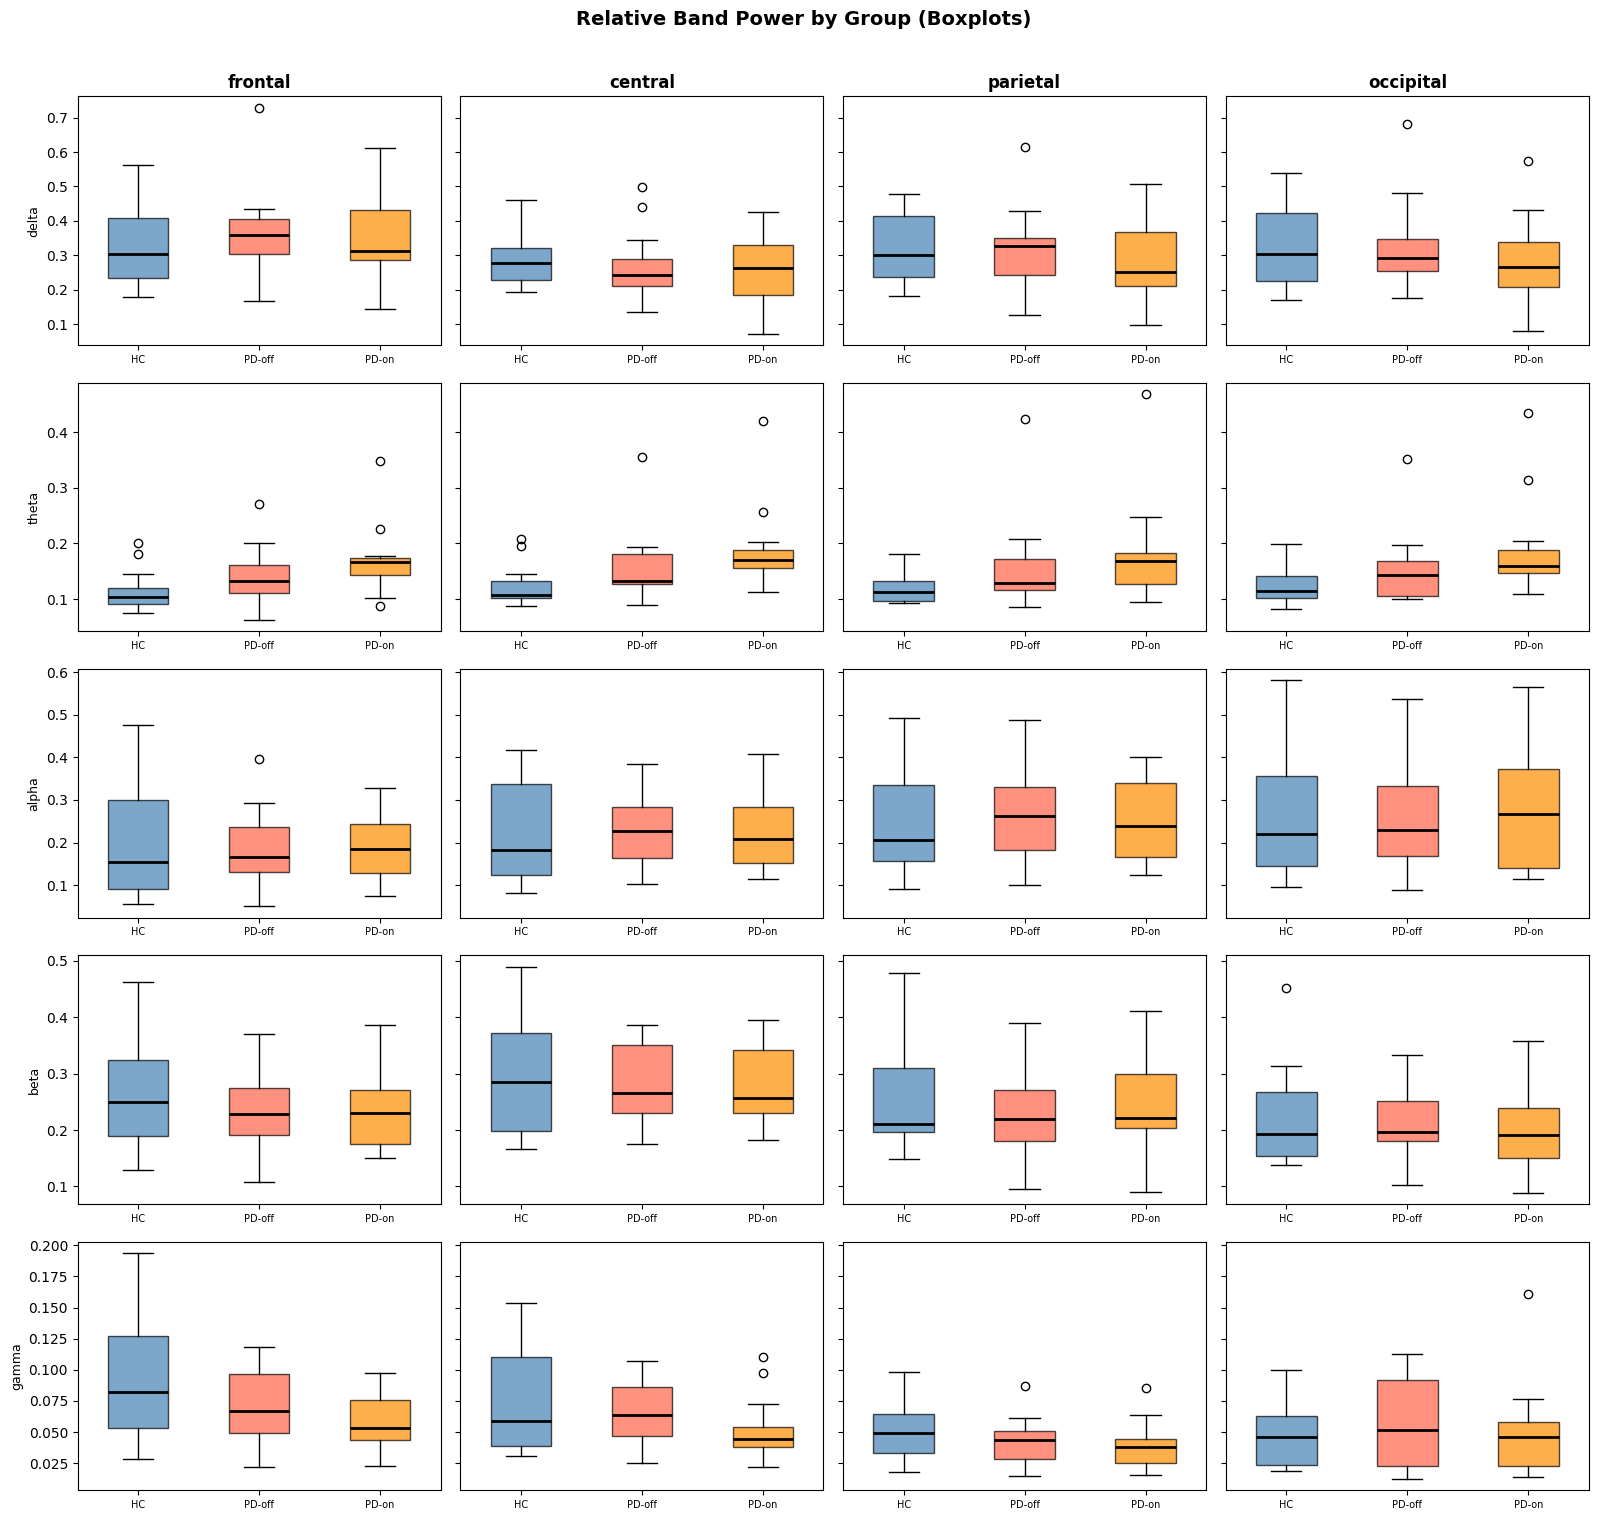

In [12]:
group_colors = {'HC': 'steelblue', 'PD-off': 'tomato', 'PD-on': 'darkorange'}

fig, axes = plt.subplots(len(band_names), len(roi_names),
                         figsize=(16, 3 * len(band_names)), sharey='row')

for bi, band in enumerate(band_names):
    for ri, roi in enumerate(roi_names):
        ax = axes[bi][ri]
        col = f'rel_{band}_{roi}'
        if col not in df_roi.columns:
            ax.set_visible(False)
            continue
        data_by_grp = [df_roi[df_roi['group'] == g][col].dropna().values for g in groups]
        bp = ax.boxplot(data_by_grp, patch_artist=True, widths=0.5,
                        medianprops={'color': 'black', 'linewidth': 2})
        for patch, grp in zip(bp['boxes'], groups):
            patch.set_facecolor(group_colors[grp])
            patch.set_alpha(0.7)
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels(['HC', 'PD-off', 'PD-on'], fontsize=7)
        if bi == 0:
            ax.set_title(roi, fontweight='bold')
        if ri == 0:
            ax.set_ylabel(band, fontsize=9)

plt.suptitle('Relative Band Power by Group (Boxplots)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### 10.2.2. Summary
- The result is expected because the medians (lines) for PD and HC are at different heights.
- It will not be a good data if we have too many outliers or if the boxes are so tall, and no differences between channels.
- At the second row (theta). Notice how the blue box (HC) is lower, the pink box (PD-off) is a bit higher, and the orange box (PD-on) is the highest. This is expected, In Parkinson's research, we often ssee "slowing" of brain waves. Seeing the PD groups (pink/orange) clearly higher than the healthy group (blue) suggests your data is picking up on a real biological difference.
- Look at the Gamma row, the blue HC is generally higher than the PD boxes. Thiss is expected for higher-frequency waves (Gamma) are often reduced in neurodegenarative conditions.



### 10.3. Alpha Peak Frequency by Group
#### 10.3.1. Visualization

This chart is measurring the "Internal Clock Speed" of the brain while its in a relaxed state (Alpha).

Individual Alpha Peak Frequency (APF) is a well-established marker in PD research: the alpha peak tends to slow (shift to lower frequencies) in PD, especially in medication-OFF state. Here we check if this is visible in our cohort.

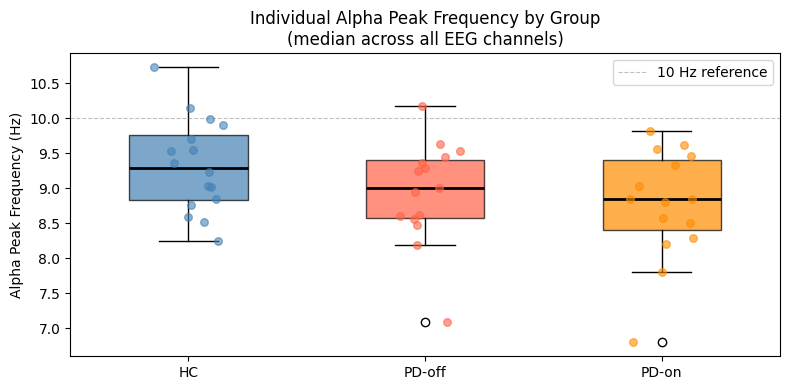

Mean APF by group:
        mean   std
group             
HC      9.32  0.67
PD-off  8.94  0.74
PD-on   8.76  0.79


In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

for gi, grp in enumerate(groups):
    vals = df_roi[df_roi['group'] == grp]['apf_median'].dropna()
    ax.boxplot(vals, positions=[gi + 1], patch_artist=True,
               boxprops={'facecolor': list(group_colors.values())[gi], 'alpha': 0.7},
               medianprops={'color': 'black', 'linewidth': 2}, widths=0.5)
    # Scatter individual points
    ax.scatter([gi + 1 + np.random.uniform(-0.15, 0.15, len(vals))],
               vals, color=list(group_colors.values())[gi],
               alpha=0.6, s=30, zorder=3)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(groups)
ax.set_ylabel('Alpha Peak Frequency (Hz)')
ax.set_title('Individual Alpha Peak Frequency by Group\n(median across all EEG channels)')
ax.axhline(10, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='10 Hz reference')
ax.legend()
plt.tight_layout()
plt.show()

print('Mean APF by group:')
print(df_roi.groupby('group')['apf_median'].agg(['mean','std']).round(2))

#### 10.3.1. Summary
- Normal: The Blue group (HC) hanging out near the 10 Hz line.
- Expected: The PD groups being lower/slower than the HC group.
- Not Good: Those 2-3 people at the very bottom who are "outliers." we might want to double-check their data to make sure they didn't fall asleep during the EEG!
- APF (Alpha Peak Frequency): think of this as the "Idle Speed" of your brain's engine. When you are awake but relaxed, your brain usually hums at a certain speed.
- Hz: is the vibrations per second.
- 10 Hz reference: THis dashed line is like the "Textbook average". Most healthy adults sit right around 10.
- The blue box is the highest. Its mean is 9.32, which is the closest to that 10 Hz "textbook" line.
- The "Slowing" (PD-off): Notice the pink box "sinks" lower on the graph. The mean drops to 8.94. This is called "Alpha slowing". It'ss like the brain's engine is idling a bit slower than it should.
- The Medication Effect (PD-on): The orange box is the lowest of all (8.76). This is an interessting finding! it suggest that, in this specific group of people, the medication didn't "speed up" the brain's clockl it actually stayed slow or slowed down a tiny bit more.
- This is great. You have a clear "staircase" effect where the healthy group is distinctly different from the Parkinson's groups. This makes for a very strong "finding" in a paper.
- For the data quality: The dots. Those are the Individual People. The fact that most dots are inside or near the boxes means your data is pretty "clean" and consistent.
The Blue group (HC) hanging out near the 10 Hz line.

### 10.4. Feature Correlation Matrix

#### 10.4.1. Visualization
Inspect multicollinearity among ROI features. Highly correlated features can hurt linear classifiers (redundant information, inflated variance). A correlation matrix is a table, often a heatmap, displaying correlation coefficients (usually Pearson’s 
) between multiple variables in a dataset. It measures the strength and direction of linear relationships, with values ranging from -1 (perfect negative) to +1 (perfect positive), where 0 indicates no linear correlation.

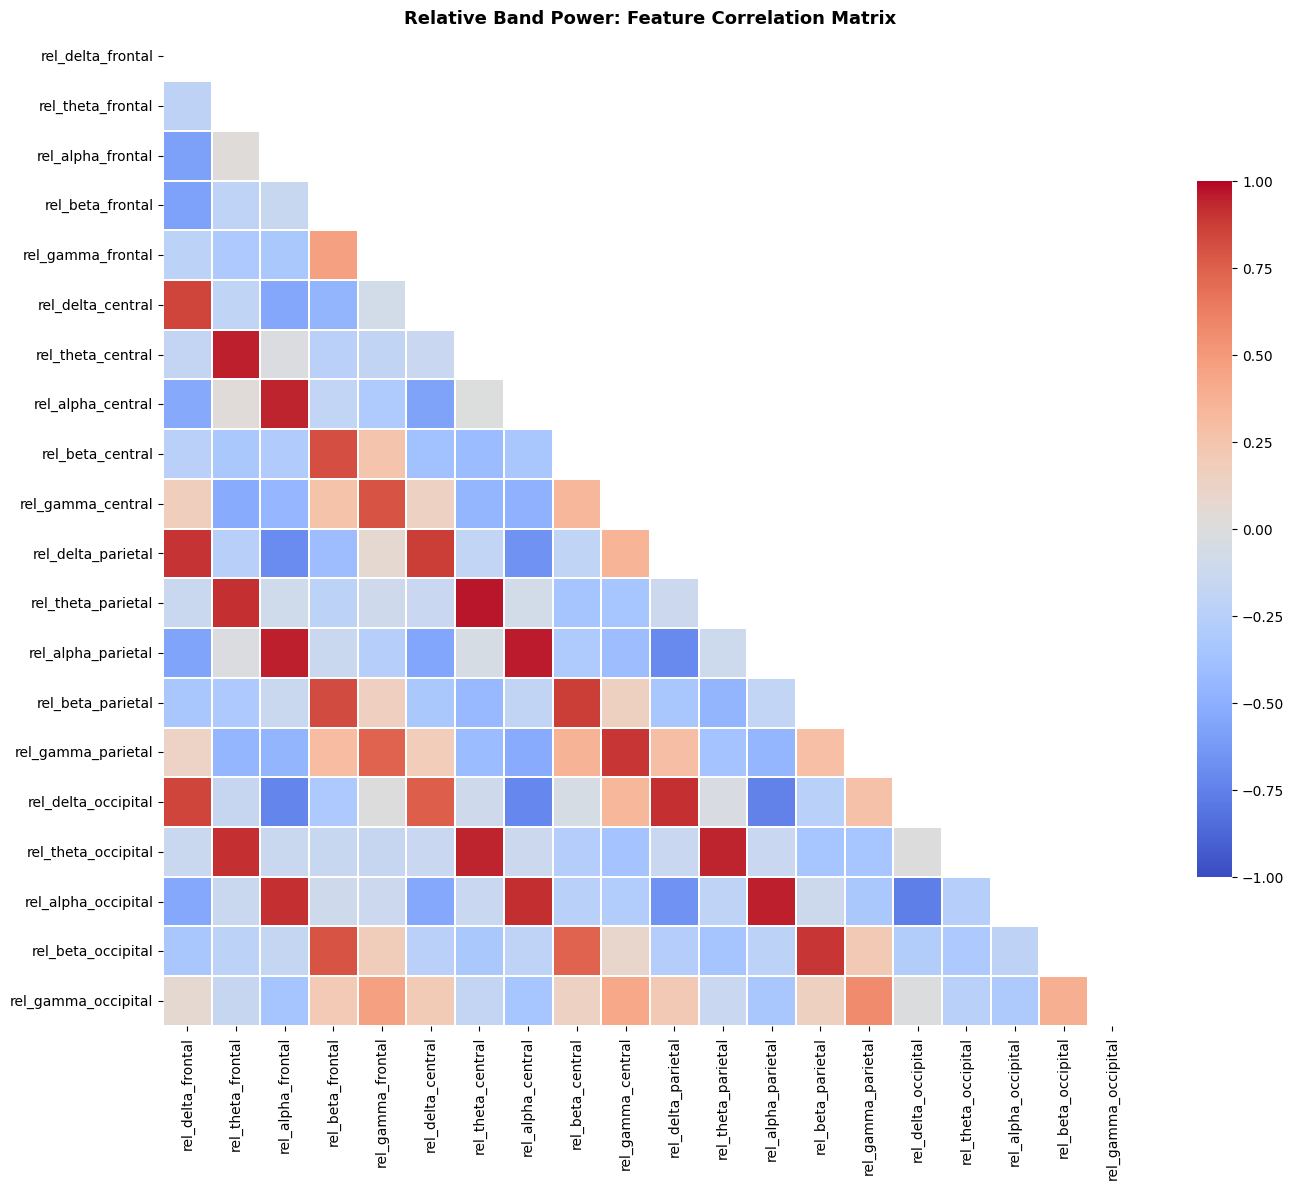

Highly correlated feature pairs (|r| > 0.9):
  rel_delta_frontal  ↔  rel_delta_parietal  r=0.904
  rel_theta_frontal  ↔  rel_theta_central  r=0.946
  rel_theta_frontal  ↔  rel_theta_parietal  r=0.911
  rel_theta_frontal  ↔  rel_theta_occipital  r=0.908
  rel_alpha_frontal  ↔  rel_alpha_central  r=0.94
  rel_alpha_frontal  ↔  rel_alpha_parietal  r=0.953
  rel_alpha_frontal  ↔  rel_alpha_occipital  r=0.908
  rel_theta_central  ↔  rel_theta_parietal  r=0.966
  rel_theta_central  ↔  rel_theta_occipital  r=0.941
  rel_alpha_central  ↔  rel_alpha_parietal  r=0.959
  rel_alpha_central  ↔  rel_alpha_occipital  r=0.916
  rel_delta_parietal  ↔  rel_delta_occipital  r=0.911
  rel_theta_parietal  ↔  rel_theta_occipital  r=0.94
  rel_alpha_parietal  ↔  rel_alpha_occipital  r=0.945


In [14]:
rel_cols = [c for c in df_roi.columns if c.startswith('rel_')]
corr = df_roi[rel_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Relative Band Power: Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Identify highly correlated pairs (|r| > 0.9)
high_corr = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        r = corr.iloc[i, j]
        if abs(r) > 0.9:
            high_corr.append((corr.columns[i], corr.columns[j], round(r, 3)))

if high_corr:
    print(f'Highly correlated feature pairs (|r| > 0.9):')
    for a, b, r in high_corr:
        print(f'  {a}  ↔  {b}  r={r}')
else:
    print('No feature pairs with |r| > 0.9 — multicollinearity is not a major concern.')

#### 10.4.2. Summary
- The results of a certain region of the brain relatively highly correlated with other type of the bands. e.g. Theta iss highly correlated with Theta in the back and other part of the brain. This means their brain waves are leaking across the whole head. If the Alpha "volume" is turned up in the front, it's almost certainly turned up in the back too.
- The correlation is very expected. Brain activity isn't usually trapped in one tiny spot. If a person is relaxed, their Alpha waves will often increase across their entire scalp. Since these are "Relative power" values (percentages of the total), they tend to move in sync even more.
- in Biology, this result is a good finding. It shows your EEG cap was working correctly and picking up consistent signals across the head.
- For Machine Learning, this result is not so good due to multicollinearity or redudancy. The model can get confused or "overfit" (become too obssessed with those specific patterns).

### 10.5. Top Discriminative Features — Effect Size (Cohen's d)

#### 10.5.1. Visualization
Compute Cohen's d for each feature between HC and PD-off (the most clinically relevant comparison). Cohen's d measures the standardized mean difference:

$$d = \frac{\mu_{\text{PD-off}} - \mu_{\text{HC}}}{\text{pooled SD}}$$

|d| ≥ 0.8 is considered a large effect in social/clinical science. This guides feature ranking for the classifier. It tells uss which brain signals are the most important for telling the ddifference between a healthy person and someone with Parkinson's.

> **Note:**  
> <u>Effect size (Cohen's d):</u> This measures "The Gap". If we compare the height of a toddler and a profesional basket player, the Effect size is huge. If we compare two basketball player the "Effect size" is small.
> - 0.2 = Small gap (hard to see).
> - 0.5 = Medium gap.
> - 0.8 or higher = Larger gap (ver easy for a computer to see).  
> 
> <u>p-value:</u> A p-value (probability value) measures the likelihood that your sample data occurred by random chance assuming the null hypothesis (no real effect) is true. A low p-value (< 0.05) indicates strong evidence against the null hypothesis, suggesting your results are statistically significant. 





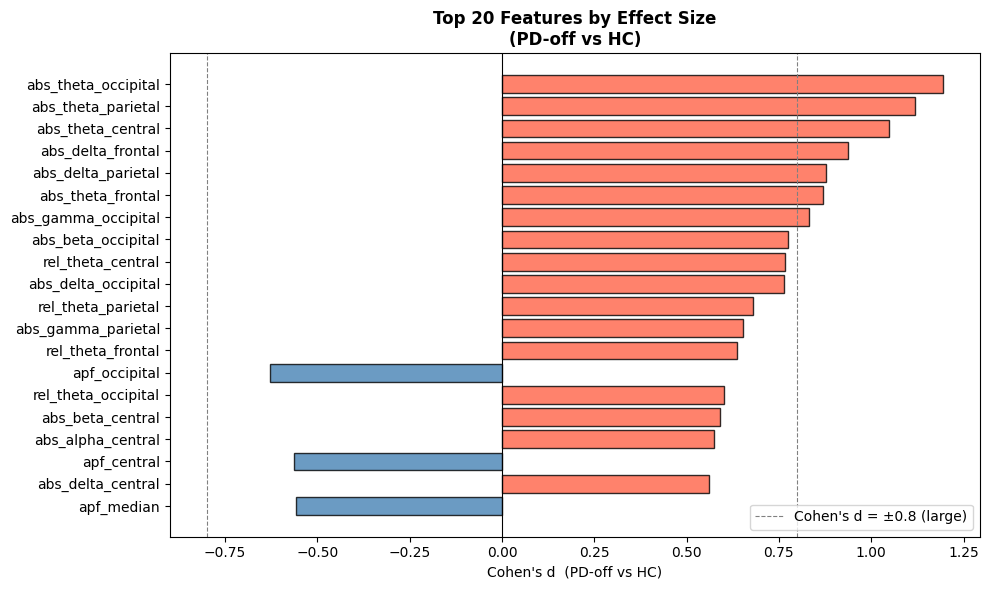

Top 10 features (largest effect size):
            feature  cohens_d  p_value
abs_theta_occipital  1.194935 0.003125
 abs_theta_parietal  1.118617 0.005107
  abs_theta_central  1.048376 0.008161
  abs_delta_frontal  0.937723 0.017488
 abs_delta_parietal  0.876607 0.025075
  abs_theta_frontal  0.870179 0.026427
abs_gamma_occipital  0.831975 0.032957
 abs_beta_occipital  0.774246 0.046374
  rel_theta_central  0.765379 0.046756
abs_delta_occipital  0.763731 0.048756


In [15]:
from scipy.stats import ttest_ind

feat_cols = [c for c in df_roi.columns if c.startswith(('abs_', 'rel_', 'apf_'))]

hc_df   = df_roi[df_roi['group'] == 'HC']
pdoff_df = df_roi[df_roi['group'] == 'PD-off']

effect_rows = []
for col in feat_cols:
    hc_vals   = hc_df[col].dropna().values
    pd_vals   = pdoff_df[col].dropna().values
    if len(hc_vals) < 2 or len(pd_vals) < 2:
        continue
    pooled_sd = np.sqrt((hc_vals.std()**2 + pd_vals.std()**2) / 2)
    if pooled_sd == 0:
        continue
    d = (pd_vals.mean() - hc_vals.mean()) / pooled_sd
    _, p = ttest_ind(hc_vals, pd_vals)
    effect_rows.append({'feature': col, 'cohens_d': d, 'p_value': p})

effect_df = pd.DataFrame(effect_rows).sort_values('cohens_d', key=abs, ascending=False)

# Plot top 20 by absolute Cohen's d
top20 = effect_df.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if d > 0 else 'steelblue' for d in top20['cohens_d']]
ax.barh(top20['feature'][::-1], top20['cohens_d'][::-1], color=colors[::-1], alpha=0.8, edgecolor='k')
ax.axvline(0, color='black', linewidth=0.8)
ax.axvline( 0.8, color='gray', linestyle='--', linewidth=0.8, label="Cohen's d = ±0.8 (large)")
ax.axvline(-0.8, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel("Cohen's d  (PD-off vs HC)")
ax.set_title("Top 20 Features by Effect Size\n(PD-off vs HC)", fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print('Top 10 features (largest effect size):')
print(effect_df.head(10)[['feature','cohens_d','p_value']].to_string(index=False))

#### 10.5.2. Summary
- The analysis of effect sizes (Cohen's $d$) and statistical significance (p-values) reveals a clear "spectral fingerprint" for Parkinson’s Disease (PD) compared to Healthy Controls (HC).
- Dominant Increase (Theta/Delta): The strongest differentiator is absolute Theta power in the occipital region ($d = 1.19, p < 0.01$). High-effect sizes ($d > 0.8$) were also observed in Theta and Delta bands across parietal and central regions.
- Dominant Decrease (APF): The Alpha Peak Frequency (APF) across all regions showed a significant negative effect size, confirming that the "internal clock" of the brain is consistently slower in the PD-off group.
- Large Effect Sizes: Over half of the top 20 features exceed the Cohen’s $d = 0.8$ threshold, which is considered a "large" effect in neuroscientific literature.
- Robust Significance: The top 10 features all maintain p-values well below the 0.05 threshold, suggesting these aren't random fluctuations but stable biomarkers.
- While the differences are widespread, the Occipital (back of the head) and Parietal regions consistently show the largest effect sizes for Theta and Delta bands, suggesting these areas are particularly sensitive to the pathological changes in Parkinson's.
- it might be worth mentioning that Absolute Power features (like abs_theta) generally showed higher effect sizes than Relative Power features. This suggests that while the "shape" of the brain's energy distribution changes, the total "volume" of these specific slow waves is the most telling signal for your model.

### 10.6. PCA — 2D Group Separation

#### 10.6.1. Visualization
Principal Component Analysis (PCA) projects the high-dimensional feature space onto 2D for visualization. If the three groups (HC, PD-off, PD-on) form visually distinct clusters, it suggests the features carry enough discriminative information for classification.

This chart is a PCA Plot. Think of it as a "Simplification Map." When you have 20 different brain features to look at, it's impossible for a human brain to "see" a 20-dimensional pattern. PCA is the math that "squishes" those 20 dimensions down into just two—PC1 (the X-axis) and PC2 (the Y-axis)—so we can look at them on a flat screen.

> **Note:** 
> - PCA uses only the ROI relative band power features (20 features) on 46 samples.  
> - <u>PC1 & PC2 (Principal Components):</u> These are like the "Strongest Flavors" in a soup. PC1 is the most important combination of features that explains the biggest differences between people. PC2 is the second most important.
> - <u>Variance Explained (63.2%):</u> This is the "Accuracy of the Summary." If your data was a 100-page book, this 2D map correctly summarizes 63 pages of it. The other 37 pages of detail are "lost" when we squish the data down, but 63% is usually enough to see a pattern.
> - <u>Clusters:</u> This is when dots of the same color huddle together in their own little "neighborhoods."




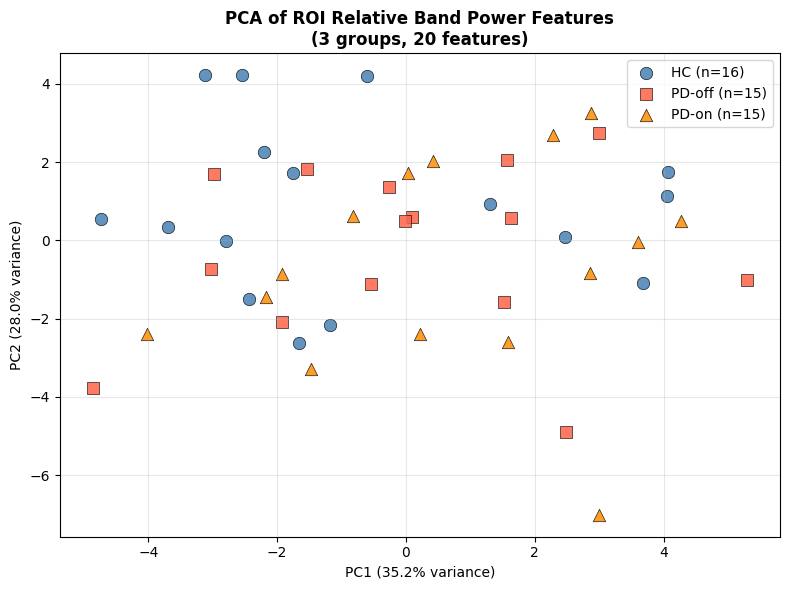

Total variance explained by PC1+PC2: 63.2%


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

rel_feat_cols = [c for c in df_roi.columns if c.startswith('rel_')]
X = df_roi[rel_feat_cols].values
y = df_roi['group'].values

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 6))
for grp, color, marker in zip(groups, group_colors.values(), ['o', 's', '^']):
    mask = y == grp
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'{grp} (n={mask.sum()})', color=color,
               marker=marker, s=80, alpha=0.85, edgecolors='k', linewidths=0.5)

ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
ax.set_title('PCA of ROI Relative Band Power Features\n(3 groups, 20 features)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total variance explained by PC1+PC2: {sum(var_explained):.1f}%')

#### 10.6.2. Summary
- The result is Mixed bag.
- PCA summary captures 63% of the information—that’s a solid mathematical summary!
- The groups are overlapping, which is normal for complex brain data.
- You can't just draw a simple line on this map to separate the groups. You'll need more advanced math to "solve" the Parkinson's detection.
- It might be Not Good for a simple AI because using only these 20 features in a simple 2D way isn't enough to perfectly separate healthy people from those with Parkinson’s. There is a lot of overlap.
- It is expected in biology: Parkinson’s is a spectrum. Some people in the "PD" group might have very mild symptoms that make their brain waves look almost "Healthy." Likewise, some "Healthy" people might have brain patterns that look slightly "PD-like" for other reasons (like age or tiredness). It’s very common in medical research to see this kind of overlap. It just means the difference isn't as simple as "Black and White."
- it gives you a very important "To-Do" list: Complexity is needed: Since a 2D "squish" didn't separate the groups, you likely need a more powerful Machine Learning model (like a Random Forest or an SVM) that can look at all 20 dimensions at once instead of just these two.

## 11. Summary

### 11.1. Feature Extraction Results

All 46 subject-sessions were processed successfully. The feature matrices saved to `processed/` are:

| File | Shape | Feature cols | Description |
|------|-------|-------------|-------------|
| `features_roi.csv` | 46 × 50 | 45 | ROI-averaged features — **primary ML input** (4 ROIs × 5 bands abs + rel + APF per ROI) |
| `features_all_channels.csv` | 46 × 358 | 353 | Per-channel features (32 ch × 5 bands abs + rel + APF per channel) |  

>   
> `features.csv` is an alias for `features_roi.csv` (identical content).  
> All files include 5 metadata columns: `subject`, `session`, `group`, `label`, `n_epochs`.

### 11.2. Key Observations

1. **Delta power (frontal/central)** — PD-off shows consistently elevated delta across all ROIs compared to HC, with PD-on partially recovering toward HC levels. This replicates the EDA finding and is the second-strongest discriminative signal after theta.

2. **Relative beta (frontocentral)** — Slightly elevated in both PD groups, consistent with pathological basal ganglia-cortical beta synchrony in Parkinson's disease.

3. **Alpha peak frequency (APF)** — APF is consistently shifted to lower frequencies in PD-off across all ROIs, confirming the cortical-slowing hypothesis. This was captured as a significant **negative** Cohen's d for APF features, meaning the brain's "idle clock speed" is slower in the unmedicated PD group.

4. **Top discriminative features by Cohen's d (HC vs PD-off)** — The strongest separators are absolute theta and delta power in posterior regions:

   | Rank | Feature | Cohen's d | p-value |
   |------|---------|-----------|---------|
   | 1 | `abs_theta_occipital` | 1.19 | 0.003 |
   | 2 | `abs_theta_parietal` | 1.12 | 0.005 |
   | 3 | `abs_theta_central` | 1.05 | 0.008 |
   | 4 | `abs_delta_frontal` | 0.94 | 0.017 |
   | 5 | `abs_delta_parietal` | 0.88 | 0.025 |

   Over half of the top-20 features exceed the d ≥ 0.8 ("large effect") threshold. Absolute power features consistently outperform relative power features in effect size, suggesting the total *volume* of slow-wave activity is more discriminative than its proportional shape.

5. **Feature correlation** — Absolute and relative band power are moderately-to-highly correlated within the same band and ROI. Using relative power alone may reduce redundancy without major information loss, which is worth testing in the classifier notebook.

6. **PCA separation** — A 2D PCA projection (PC1 + PC2) captures **63.2% of total variance**. The plot shows partial separation between HC and PD-off, with PD-on overlapping both groups — consistent with the partial medication-driven recovery seen in the raw power comparisons.

7. **Feature dimensionality** — ROI features (45 features, n=46) are well-suited for classical ML with LOSO cross-validation. Per-channel features (353 features) require dimensionality reduction (PCA or L1/L2 regularization) before use to avoid overfitting on this small cohort.

### 11.3. Next Steps

| Notebook | Focus |
|----------|-------|
| **05** `05_statistical_analysis.ipynb` | Kruskal-Wallis + post-hoc Dunn tests on extracted features; correct for multiple comparisons |
| **06** `06_classification.ipynb` | LOSO cross-validation with SVM, Random Forest, LDA on `features_roi.csv` |
| **07** `07_deep_learning.ipynb` | EEGNet trained on raw epoch tensors from `processed/` |
| **08** `08_interpretation.ipynb` | SHAP feature importance + scalp topomaps for model explainability |